In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


In [8]:
import sys
sys.path.append("/home/yigit/codebase/dna2vec/evaluate")
sys.path.append("/home/yigit/codebase/dna2vec/src")
import os
import hydra
import logging
import numpy as np
import pandas as pd

### LOAD DATA

In [9]:
#eval_results = pd.read_csv("/home/yigit/codebase/dna2vec/evaluate/playground/results_df_2025_04_01_19_20_38_topk_25000.csv")
#eval_results = pd.read_csv("/home/yigit/codebase/dna2vec/evaluate/playground/results_df_sw_and_idx_comparisons (1).csv")
eval_results = pd.read_csv("/home/mehmet/codebase/dna2vec/outputs/2025-05-05/14-20-53/results_chr19_all_50_1000000_2025_05_05_15_49_20/results_refined.csv")

In [10]:
eval_results

,enum,read_gt,read_gt_idx,read_gt_cigar_str,read/frag_gt_reference_interval,is_read_gt_index_exist_in_top75,read/frag_gt_top75_index,is_read/frag_gt_top_match_in_top75,read/frag_gt,read/frag_gt_idx,...,third_best_alignment_str,alignment_cigar_str,second_best_alignment_cigar_str,third_best_alignment_cigar_str,modified_alignment_cigar_str,second_modified_alignment_cigar_str,third_modified_alignment_cigar_str,read/frag_gt_alignment_index,read/frag_gt_alignment_str,read_gt_idx_diff_from_read/frag_gt_index
0,0,CATAGGGGTCCACCTCCGAGCTCTGCAAATTTTTTTCGATTTCCGC...,552313,83S165M,"[552000, 553300]",True,0.0,True,ATTTTTAGTAGAGACTAATAGAAACACAGGTTTCACCACGTTGACC...,552230.0,...,target 65 CATTTGATCAAATCACAACTTTAATA...,248M,3M35D32M35D3M12D3M19D5M21D3M1I3M14D4M21D3M22D3...,3M66D3M23D2M12D12M12D2M1D4M51D1M5D1M7D7M38D5M9...,248M,174S74M563D,184S64M416D,[[[230 478]]\n\n [[ 0 248]]],target 313 ----------------------------...,83.0
1,1,TTTTAGAGATAGGATTTTGAAAATTAGCTGGGCATGGTGGCGCGTG...,1680316,197M53S,No match,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,ACGCCCAGCTAACTTTTTTTGTATTTTTAGTAGAGACTAATAGAAA...,551978,155M65S,No match,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,CCAGCTTCCTTAAGGGGCAGTGTATTGATGGGGGAAACACCAGGGG...,1740866,64S186M,No match,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,TGGTGGTGACACCTAACACCTTTGCCCTATTCTGTTGGCTACACGG...,1740743,142M108S,No match,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1758,1758,ATTAATGAAACAAAAAAGTTAACAGTAGAGGATTAATAAAACTAAG...,59096913,178M72S,No match,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1759,1759,CAAGCTCTGCCTTTTCCTGGCCATGTGACTCTCTTGAAGACATGGC...,58921739,170M80S,"[58921000, 58922300]",True,0.0,True,GCCCTTGGCCCTGCACATAGATGGCATCAGTCTGGTCACCAACCTG...,58921739.0,...,target 4 CATGCCTGGCTGATCCATGAAGTATT...,169M244D25M1I3M1D37M1I3M1D10M,2M2D5M10D2M7D4M25D2M16D4M38D5M10D2M5D2M1I4M57D...,5M27D8M10D5M31D3M5D5M15D2M5D2M2D3M7D3M4I2M1D5M...,169M81S,2M248S,225S25M460D,[[[ 739 908]\n [1152 1177]\n [1177 1180]\n ...,target 739 CAAGCTCTGCCTTTTCCTGGCCATGTGA...,0.0
1760,1760,CAAGACTCCATCTTTTTTGTTTGTTTGTTTGTTTTGAGATGGAGTC...,59035020,185M65S,"[59035000, 59036300]",True,0.0,True,TCCAGCCTGGGAGACAAGAGCAAGACTCCATCTTTTTTGTTTGTTT...,59035020.0,...,target 34 CAAGAACAAGGTGAGGGCGGGTGGAG...,185M94D65M,185M2D2M8D4M1I1M3D4M5D2M1D2M1D3M2I3M1D4M2I1M1I...,5M77D5M14D1M1I19M1D142M405D6M168D6M20D3M79D3M4...,185M65S,185M65S,199S51M,[[[ 20 205]\n [299 364]]\n\n [[ 0 185]\n [1...,target 20 CAAGACTCCATCTTTTTTGTTTGTTTGT...,0.0
1761,1761,TGTGTTATTTTGTTTTTTGTTTTTTTTTTTCTTTTTTTTTTTTTTT...,58611331,81S168M,No match,False,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
eval_results.columns

Index(['enum', 'read_gt', 'read_gt_idx', 'read_gt_cigar_str',
       'read/frag_gt_reference_interval', 'is_read_gt_index_exist_in_top75',
       'read/frag_gt_top75_index', 'is_read/frag_gt_top_match_in_top75',
       'read/frag_gt', 'read/frag_gt_idx', 'best_sw_score_in_top75',
       'read/frag_gt_best_sw_score', 'is_read/frag_gt_sw_score_best_in_top75',
       'is_read/frag_gt_index_same_as_gt_index', 'alignment_str',
       'second_best_alignment_str', 'third_best_alignment_str',
       'alignment_cigar_str', 'second_best_alignment_cigar_str',
       'third_best_alignment_cigar_str', 'modified_alignment_cigar_str',
       'second_modified_alignment_cigar_str',
       'third_modified_alignment_cigar_str', 'read/frag_gt_alignment_index',
       'read/frag_gt_alignment_str',
       'read_gt_idx_diff_from_read/frag_gt_index'],
      dtype='object')

In [15]:
#calculate accuracy of is_read_gt_index_exist_in_top75
is_read_gt_index_exist_in_top75_accuracy = len(eval_results[eval_results["is_read_gt_index_exist_in_top75"] == True]) / (len(eval_results[eval_results["is_read_gt_index_exist_in_top75"] == True]) +len(eval_results[eval_results["is_read_gt_index_exist_in_top75"] == False]))
is_read_frag_gt_top_match_in_top75_accuracy = len(eval_results[eval_results["is_read/frag_gt_top_match_in_top75"] == True]) / (len(eval_results[eval_results["is_read/frag_gt_top_match_in_top75"] == True]) +len(eval_results[eval_results["is_read/frag_gt_top_match_in_top75"] == False]))
is_read_frag_gt_sw_score_best_in_top75_accuracy = len(eval_results[eval_results["is_read/frag_gt_sw_score_best_in_top75"] == True]) / (len(eval_results[eval_results["is_read/frag_gt_sw_score_best_in_top75"] == True]) +len(eval_results[eval_results["is_read/frag_gt_sw_score_best_in_top75"] == False]))
is_read_frag_gt_index_same_as_gt_index_accuracy = len(eval_results[eval_results["is_read/frag_gt_index_same_as_gt_index"] == True]) / (len(eval_results[eval_results["is_read/frag_gt_index_same_as_gt_index"] == True]) +len(eval_results[eval_results["is_read/frag_gt_index_same_as_gt_index"] == False]))

print("is_read_gt_index_exist_in_top75: ", is_read_gt_index_exist_in_top75_accuracy)
print("is_read/frag_gt_top_match_in_top75: ", is_read_frag_gt_top_match_in_top75_accuracy)
print("is_read/frag_gt_sw_score_best_in_top75: ", is_read_frag_gt_sw_score_best_in_top75_accuracy)
print("is_read/frag_gt_index_same_as_gt_index: ", is_read_frag_gt_index_same_as_gt_index_accuracy)


is_read_gt_index_exist_in_top75:  0.5796937039137833
is_read/frag_gt_top_match_in_top75:  0.410958904109589
is_read/frag_gt_sw_score_best_in_top75:  0.9843444227005871
is_read/frag_gt_index_same_as_gt_index:  0.7415506958250497


In [16]:
is_read_gt_index_exist_in_top75_accuracy * is_read_frag_gt_sw_score_best_in_top75_accuracy * is_read_frag_gt_index_same_as_gt_index_accuracy

0.4231423709585933

In [14]:
avg_diff_index = eval_results["read_gt_idx_diff_from_read/frag_gt_index"].mean()
print("avg_diff_index: ", avg_diff_index)

avg_diff_index:  36.69569471624266


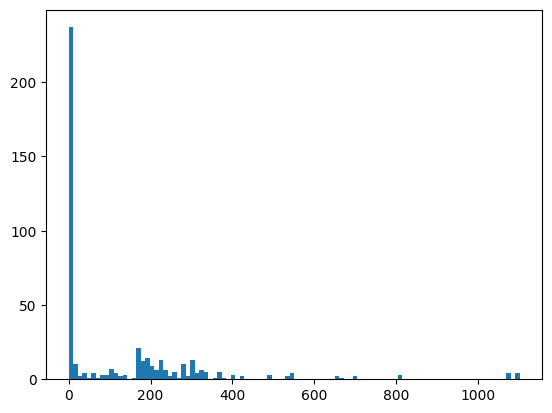

In [78]:
#plot histogram of read_gt_idx_diff_from_read/frag_gt_index
plt.hist(np.abs(eval_results["read_gt_idx_diff_from_read/frag_gt_index"]), bins=100)
plt.show()



In [79]:
local_idx = [int(idx) - int(interval.split("[")[1].split(",")[0]) for interval, idx in eval_results[eval_results["is_read_gt_index_exist_in_top75"] == True][["read/frag_gt_reference_interval", "read/frag_gt_idx"]].values]
gt_local_idx = [int(idx) - int(interval.split("[")[1].split(",")[0]) for interval, idx in eval_results[eval_results["is_read_gt_index_exist_in_top75"] == True][["read/frag_gt_reference_interval", "read_gt_idx"]].values]
fragments = [eval_results[eval_results["is_read_gt_index_exist_in_top75"] == True]["read/frag_gt_sw_score"]]
aligned_sw_scores = [eval_results[eval_results["is_read_gt_index_exist_in_top75"] == True]["read/frag_gt_best_sw_score"]]
aligned_fragments = [fragment[local_index:] for fragment, local_index in zip(fragments[0],local_idx)]
gt_aligned_fragments = [fragment[gt_local_index:] for fragment, gt_local_index in zip(fragments[0],gt_local_idx)]
aligned_reads = [eval_results[eval_results["is_read_gt_index_exist_in_top75"] == True]["read_gt"]]
start_index_diff = [eval_results[eval_results["is_read_gt_index_exist_in_top75"] == True]["read_gt_idx_diff_from_read/frag_gt_index"]]

In [80]:
for idx, (read,fragment, aligned_fragment, sw_score, gt_fragment, start_idx_diff, local_index, gt_local_index) in enumerate(zip(aligned_reads[0], fragments[0], aligned_fragments, aligned_sw_scores[0], gt_aligned_fragments, start_index_diff[0],local_idx, gt_local_idx)):
    print("Data: ", idx)
    print("Read: ", read)
    # print("DNA-RDE Aligned Read:    ", aligned_fragment[:len(read)])
    # print("GT Aligned Read:         ", gt_fragment[:len(read)])
    print("DNA-RDE Local Index: ", local_index)
    print("GT Local Index: ", gt_local_index)
    print("Start Index Difference:  ", start_idx_diff)
    print("DNA-RDE Aligned Read SW Score: ", sw_score)
    print("Calculated DNA-RDE Aligned Fragment SW Score:", calculate_smith_waterman_distance(fragment,read))
    print("Calculated DNA-RDE Aligned Fragment(Start idx is aligned) SW Score:", calculate_smith_waterman_distance(aligned_fragment,read))
    print("GT Aligned Read SW Score:      ", calculate_smith_waterman_distance(gt_fragment,read))
    print("#"*100)
    # for i in range(0,len(read),50):
    #     print("Interval: ", i, " - ", i+50)
    #     print("Read:                    ", read[i:i+50])
    #     print("DNA-RDE Aligned Read:        ", fragment[i:i+50])
    #     print("GT Aligned Read: ", gt_fragment[i:i+50])
    #     print("-"*100)
    # print("#"*100)
    # print("READ END")
    # print("#"*100)

Data:  0
Read:  GTTAGGGAGTCATCGATCTGTTCTTCATTTTCCAATGTGCTGCCATGAAACCGCATATACAGTCGCTCCTGGTTCTTCTCATCTCTCCTGCATGCCTGAGCCCTGCTCCTTCTCATGGCAAATCCTGCCTCACTCGGTGCTCTTTCTTTGTTTTCCACACTGGGTTGTGAAGCAGGGCTTCATGTTTTCTTCCCACCAGGTCTTTTATTCATAGTTAATTATTTTAACTTCTGCATGCATTAATTTAACT
DNA-RDE Local Index:  438
GT Local Index:  438
Start Index Difference:   0.0
DNA-RDE Aligned Read SW Score:  -499.5
Calculated DNA-RDE Aligned Fragment SW Score: {'elapsed time': 0.021660327911376953, 'distance': -499.5, 'begins': [438]}
Calculated DNA-RDE Aligned Fragment(Start idx is aligned) SW Score: {'elapsed time': 0.01520085334777832, 'distance': -499.5, 'begins': [0]}
GT Aligned Read SW Score:       {'elapsed time': 0.01513218879699707, 'distance': -499.5, 'begins': [0]}
####################################################################################################
Data:  1
Read:  ACTGACTAGAAGTGCGCCTTGGATTCCCTAGACTGACCAGAAGGGCTGCCTTGCACTCCCTCGAGTGACATGAATGGCTGTTTTGCACTCCCTCAGTGACCGGAAGGGCTGCCTTGGACTCTCTTGAGTGGC